Selecciona el archivo df_clasificacion_estudiantes.csv


Saving dataset_estudiantes.csv to dataset_estudiantes.csv

Dataset cargado correctamente.


,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1



El dataset tiene 1000 filas y 11 columnas.

Distribución de la variable aprobado:


,cantidad
aprobado,
0,102
1,898



Distribución porcentual:


,porcentaje
aprobado,
0,10.2
1,89.8



Dimensiones de X: (1000, 10)
Dimensiones de y: (1000,)

Variables numéricas:
['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia', 'horas_sueno', 'edad', 'nota_final']

Variables categóricas:
['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']

Registros de entrenamiento: 800
Registros de prueba: 200

Modelo de clasificación entrenado correctamente.
Predicciones realizadas correctamente.

Métricas del modelo:


,conjunto,accuracy,precision,recall,F1,ROC_AUC
0,Entrenamiento,0.974,1.0,0.971,0.985,1.0
1,Prueba,0.990,1.0,0.989,0.994,1.0



Informe de clasificación:
              precision    recall  f1-score   support

    Suspenso       0.91      1.00      0.95        20
    Aprobado       1.00      0.99      0.99       180

    accuracy                           0.99       200
   macro avg       0.95      0.99      0.97       200
weighted avg       0.99      0.99      0.99       200



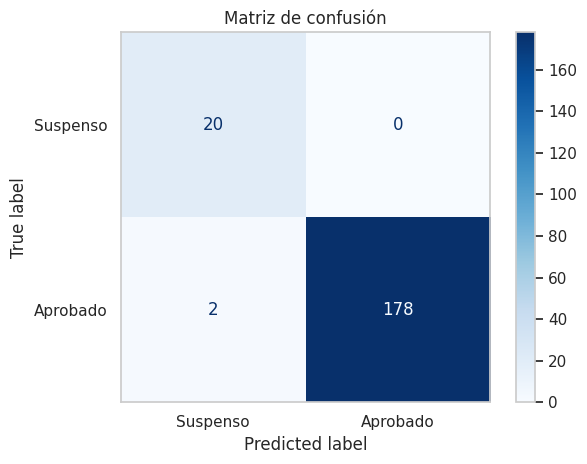

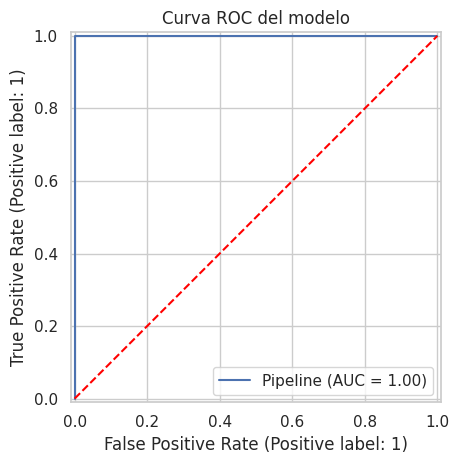


Resultados de validación cruzada:


,métrica,resultado
0,Accuracy media,0.976
1,Precision media,1.000
2,Recall medio,0.973
3,F1 medio,0.986
4,ROC-AUC medio,0.999



Ejemplo de predicciones:


,resultado_real,resultado_predicho,probabilidad_aprobado
168,1,1,1.000
929,0,0,0.001
269,1,1,1.000
750,1,1,1.000
184,0,0,0.000
677,1,1,0.955
319,1,1,1.000
136,1,1,1.000
964,1,1,1.000
450,1,1,0.999



Modelo guardado correctamente como modelo_clasificacion_estudiantes.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# ENTRENAMIENTO Y VALIDACIÓN DEL MODELO DE CLASIFICACIÓN
# ============================================================


# 1. IMPORTACIÓN DE LIBRERÍAS

import io
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


# 2. CONFIGURACIÓN

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


# 3. SUBIR Y CARGAR EL DATASET

print(
    "Selecciona el archivo "
    "df_clasificacion_estudiantes.csv"
)

archivos_subidos = files.upload()

nombre_archivo = list(
    archivos_subidos.keys()
)[0]

df = pd.read_csv(
    io.BytesIO(
        archivos_subidos[nombre_archivo]
    )
)

print("\nDataset cargado correctamente.")

display(df.head())

print(
    f"\nEl dataset tiene {df.shape[0]} filas "
    f"y {df.shape[1]} columnas."
)


# 4. COMPROBAR LA VARIABLE OBJETIVO

print("\nDistribución de la variable aprobado:")

display(
    df["aprobado"]
    .value_counts()
    .sort_index()
    .to_frame("cantidad")
)

print("\nDistribución porcentual:")

display(
    (
        df["aprobado"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
    .to_frame("porcentaje")
)


# 5. DEFINIR VARIABLES PREDICTORAS Y OBJETIVO

variable_objetivo = "aprobado"

X = df.drop(
    columns=[variable_objetivo]
)

y = df[variable_objetivo]

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)


# 6. IDENTIFICAR COLUMNAS NUMÉRICAS Y CATEGÓRICAS

columnas_numericas = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

columnas_categoricas = (
    X.select_dtypes(include="object")
    .columns
    .tolist()
)

print("\nVariables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)


# 7. DIVISIÓN EN ENTRENAMIENTO Y PRUEBA

# Stratify conserva la proporción de aprobados y suspensos.

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print(
    "\nRegistros de entrenamiento:",
    X_train.shape[0]
)

print(
    "Registros de prueba:",
    X_test.shape[0]
)


# 8. PIPELINE PARA VARIABLES NUMÉRICAS

pipeline_numerico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="median")
        ),
        (
            "escalado",
            StandardScaler()
        )
    ]
)


# 9. PIPELINE PARA VARIABLES CATEGÓRICAS

pipeline_categorico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "codificacion",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)


# 10. CREAR EL PREPROCESADOR

preprocesador = ColumnTransformer(
    transformers=[
        (
            "variables_numericas",
            pipeline_numerico,
            columnas_numericas
        ),
        (
            "variables_categoricas",
            pipeline_categorico,
            columnas_categoricas
        )
    ]
)


# 11. CREAR EL MODELO DE CLASIFICACIÓN

# class_weight="balanced" compensa el desbalance
# entre estudiantes aprobados y suspendidos.

modelo_clasificacion = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


# 12. ENTRENAR EL MODELO

modelo_clasificacion.fit(
    X_train,
    y_train
)

print(
    "\nModelo de clasificación "
    "entrenado correctamente."
)


# 13. REALIZAR PREDICCIONES

prediccion_train = (
    modelo_clasificacion.predict(X_train)
)

prediccion_test = (
    modelo_clasificacion.predict(X_test)
)

probabilidad_train = (
    modelo_clasificacion
    .predict_proba(X_train)[:, 1]
)

probabilidad_test = (
    modelo_clasificacion
    .predict_proba(X_test)[:, 1]
)

print("Predicciones realizadas correctamente.")


# 14. CALCULAR MÉTRICAS

metricas = pd.DataFrame({
    "conjunto": [
        "Entrenamiento",
        "Prueba"
    ],
    "accuracy": [
        accuracy_score(
            y_train,
            prediccion_train
        ),
        accuracy_score(
            y_test,
            prediccion_test
        )
    ],
    "precision": [
        precision_score(
            y_train,
            prediccion_train,
            zero_division=0
        ),
        precision_score(
            y_test,
            prediccion_test,
            zero_division=0
        )
    ],
    "recall": [
        recall_score(
            y_train,
            prediccion_train,
            zero_division=0
        ),
        recall_score(
            y_test,
            prediccion_test,
            zero_division=0
        )
    ],
    "F1": [
        f1_score(
            y_train,
            prediccion_train,
            zero_division=0
        ),
        f1_score(
            y_test,
            prediccion_test,
            zero_division=0
        )
    ],
    "ROC_AUC": [
        roc_auc_score(
            y_train,
            probabilidad_train
        ),
        roc_auc_score(
            y_test,
            probabilidad_test
        )
    ]
})

print("\nMétricas del modelo:")

display(metricas.round(3))


# 15. INFORME DE CLASIFICACIÓN

print("\nInforme de clasificación:")

print(
    classification_report(
        y_test,
        prediccion_test,
        target_names=[
            "Suspenso",
            "Aprobado"
        ],
        zero_division=0
    )
)


# 16. MATRIZ DE CONFUSIÓN

matriz_confusion = confusion_matrix(
    y_test,
    prediccion_test
)

visualizacion = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=[
        "Suspenso",
        "Aprobado"
    ]
)

visualizacion.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusión")
plt.grid(False)
plt.tight_layout()
plt.show()


# 17. CURVA ROC

RocCurveDisplay.from_estimator(
    modelo_clasificacion,
    X_test,
    y_test
)

plt.title("Curva ROC del modelo")
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="red"
)

plt.tight_layout()
plt.show()


# 18. VALIDACIÓN CRUZADA ESTRATIFICADA

validacion = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cv = cross_validate(
    modelo_clasificacion,
    X,
    y,
    cv=validacion,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

resumen_cv = pd.DataFrame({
    "métrica": [
        "Accuracy media",
        "Precision media",
        "Recall medio",
        "F1 medio",
        "ROC-AUC medio"
    ],
    "resultado": [
        resultados_cv[
            "test_accuracy"
        ].mean(),

        resultados_cv[
            "test_precision"
        ].mean(),

        resultados_cv[
            "test_recall"
        ].mean(),

        resultados_cv[
            "test_f1"
        ].mean(),

        resultados_cv[
            "test_roc_auc"
        ].mean()
    ]
})

print(
    "\nResultados de validación cruzada:"
)

display(resumen_cv.round(3))


# 19. TABLA DE PREDICCIONES

comparacion = X_test.copy()

comparacion["resultado_real"] = (
    y_test.values
)

comparacion["resultado_predicho"] = (
    prediccion_test
)

comparacion["probabilidad_aprobado"] = (
    probabilidad_test
)

print("\nEjemplo de predicciones:")

display(
    comparacion[
        [
            "resultado_real",
            "resultado_predicho",
            "probabilidad_aprobado"
        ]
    ]
    .head(10)
    .round(3)
)


# 20. ENTRENAR EL MODELO FINAL

modelo_clasificacion.fit(X, y)


# 21. GUARDAR Y DESCARGAR EL MODELO

joblib.dump(
    modelo_clasificacion,
    "modelo_clasificacion_estudiantes.pkl"
)

print(
    "\nModelo guardado correctamente como "
    "modelo_clasificacion_estudiantes.pkl"
)

files.download(
    "modelo_clasificacion_estudiantes.pkl"
)

In [ ]:
## Conclusiones del modelo de clasificación

Se ha entrenado un modelo de regresión logística para predecir si un estudiante aprobará o suspenderá. Los datos se dividieron en un 80 % para entrenamiento y un 20 % para prueba, manteniendo en ambos conjuntos la proporción de las clases mediante una división estratificada.

Las variables numéricas fueron imputadas y estandarizadas. Las variables categóricas fueron imputadas y transformadas mediante One-Hot Encoding. Todo el preprocesamiento se realizó dentro de un pipeline para evitar la fuga de información.

Debido al desbalance de la variable objetivo, se utilizó el parámetro `class_weight="balanced"`. El modelo se evaluó mediante accuracy, precision, recall, F1-score, ROC-AUC, matriz de confusión y curva ROC. También se aplicó validación cruzada estratificada de cinco particiones.

El análisis conjunto de estas métricas permite evaluar tanto la capacidad general del modelo como su eficacia para identificar a los estudiantes que podrían suspender.